#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

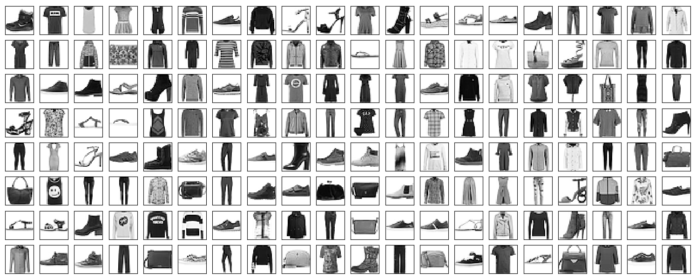


In [35]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [36]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

In [37]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [38]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

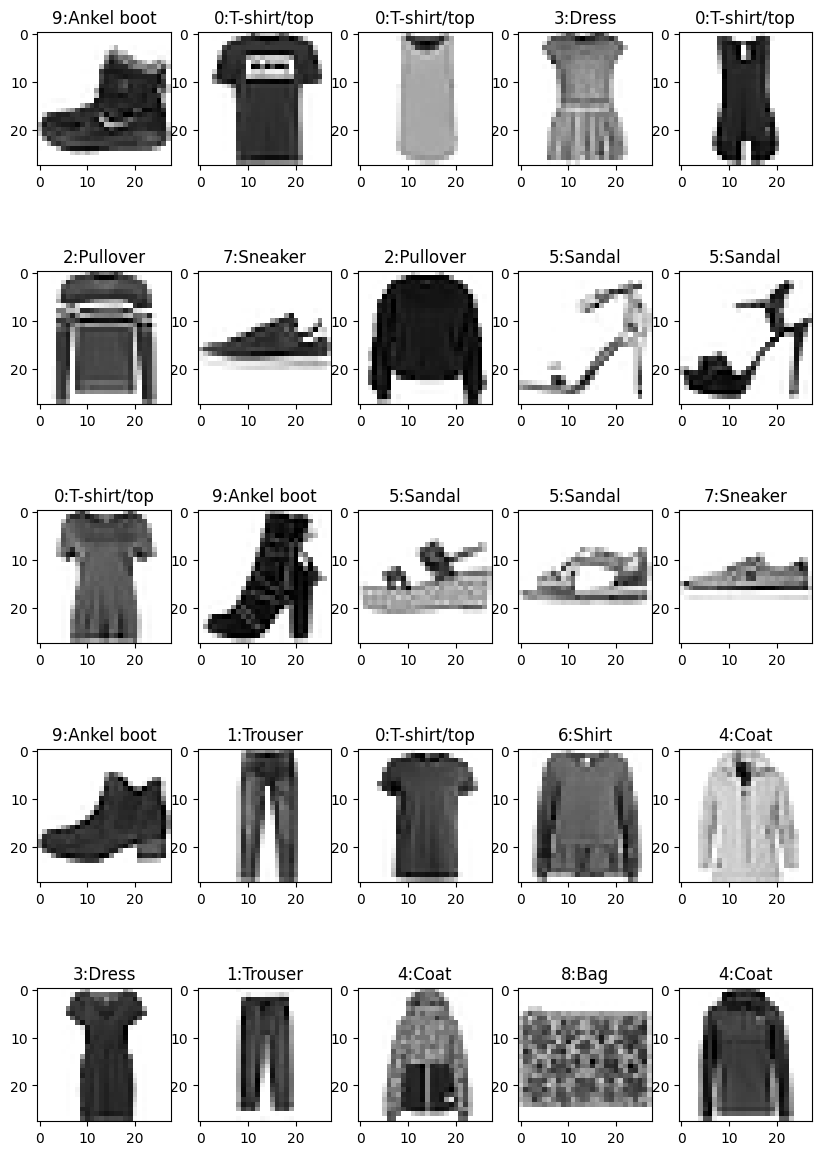

In [39]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [40]:
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [41]:
x_train = x_train / 255
x_test = x_test / 255

#모델구성

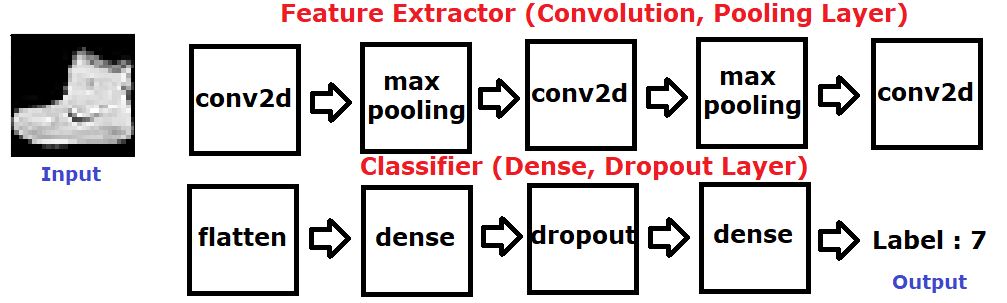

## Feature Extractor

In [42]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [43]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7905 - loss: 0.5881

KeyboardInterrupt: 

In [ ]:
def plot_history(history):
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plt.plot(history['acc'])
    plt.plot(history['val_acc'])
    plt.legend(['train', 'val'])
    plt.title('accuracy')
    plt.subplot(1,2,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.legend(['train', 'val'])
    plt.title('loss')
    plt.show()  

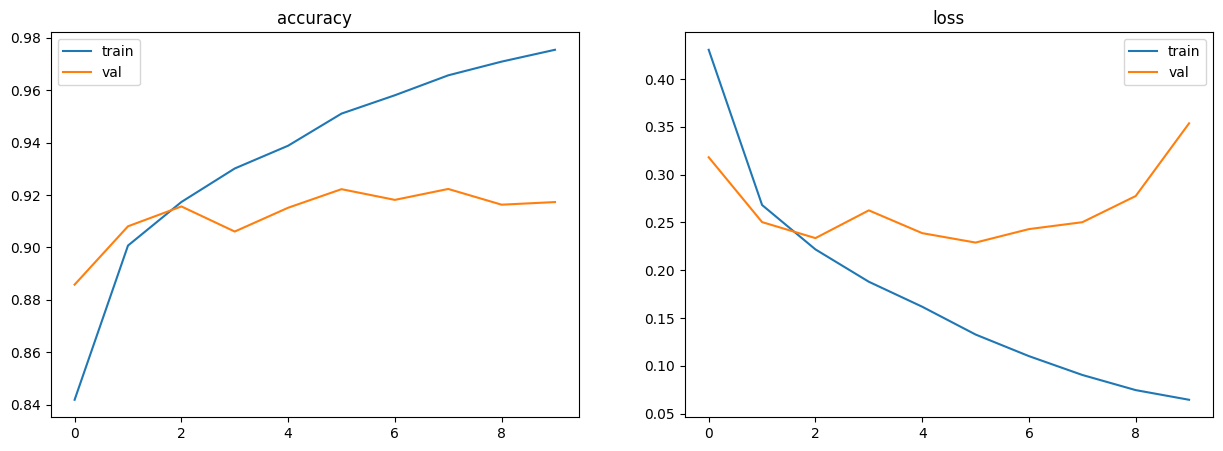

In [ ]:
plot_history(history.history)

# Drop out
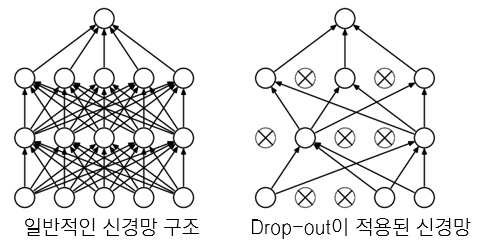

## BatchNormalization
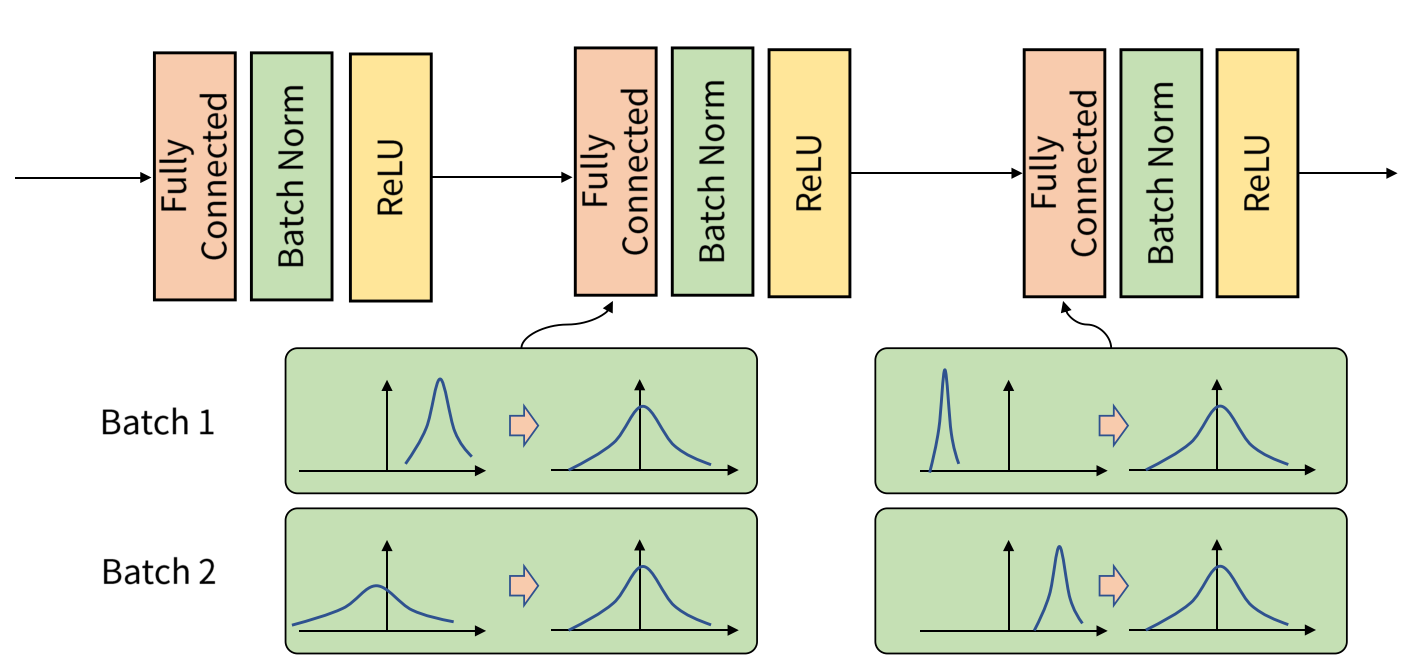

In [ ]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [ ]:
history = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.8537 - loss: 0.4113 - val_acc: 0.8803 - val_loss: 0.3257
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.8981 - loss: 0.2798 - val_acc: 0.8942 - val_loss: 0.2913
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9131 - loss: 0.2402 - val_acc: 0.9033 - val_loss: 0.2695
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9233 - loss: 0.2094 - val_acc: 0.9070 - val_loss: 0.2615
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - acc: 0.9317 - loss: 0.1862 - val_acc: 0.9105 - val_loss: 0.2685
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9385 - loss: 0.1653 - val_acc: 0.9066 - val_loss: 0.2955
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9452 - loss: 0.1455 - val_acc: 0.9206 - val_loss: 0.2622
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9490 - loss: 0.1366 - val_acc: 0.9145 - val_loss: 0.2802
Epoch 9/10
1500/1500 ━━━━━━━━━━

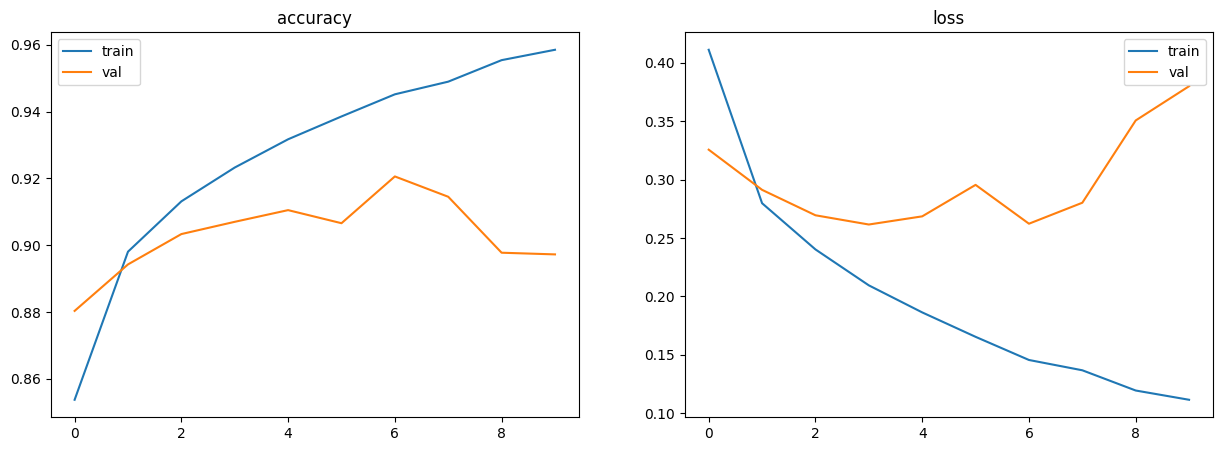

In [ ]:
plot_history(history.history)

In [ ]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8925 - loss: 0.4092


[0.4091554284095764, 0.8924999833106995]

## Callback

In [ ]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model3.add(layers.Dropout(0.3))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model3.add(layers.Flatten())
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(10, activation='softmax'))
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.h5')
history = model3.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb])

Epoch 1/10
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.7639 - loss: 0.6512

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.8331 - loss: 0.4673 - val_acc: 0.8892 - val_loss: 0.3169
Epoch 2/10
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8868 - loss: 0.3115

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.8901 - loss: 0.3017 - val_acc: 0.8879 - val_loss: 0.2950
Epoch 3/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9033 - loss: 0.2633

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9066 - loss: 0.2570 - val_acc: 0.9116 - val_loss: 0.2402
Epoch 4/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9157 - loss: 0.2300

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9161 - loss: 0.2271 - val_acc: 0.9100 - val_loss: 0.2400
Epoch 5/10
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9243 - loss: 0.2022

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9322 - loss: 0.1829 - val_acc: 0.9152 - val_loss: 0.2309
Epoch 7/10
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9407 - loss: 0.1578

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9387 - loss: 0.1641 - val_acc: 0.9128 - val_loss: 0.2390
Epoch 8/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9442 - loss: 0.1465

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9438 - loss: 0.1502 - val_acc: 0.9201 - val_loss: 0.2211
Epoch 9/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9505 - loss: 0.1308

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9493 - loss: 0.1351 - val_acc: 0.9145 - val_loss: 0.2492
Epoch 10/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9557 - loss: 0.1201

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9531 - loss: 0.1260 - val_acc: 0.9193 - val_loss: 0.2417


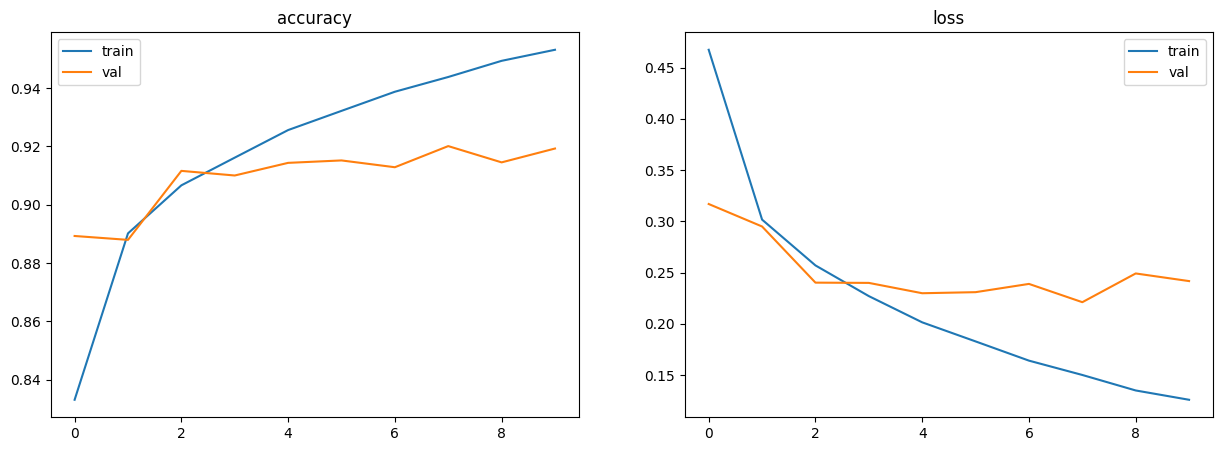

In [ ]:
plot_history(history.history)

In [ ]:
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9124 - loss: 0.2677


[0.267668753862381, 0.9124000072479248]

In [ ]:
pred=model3.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.001 0.    0.999 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.022 0.    0.005 0.    0.003 0.    0.97  0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.032 0.    0.968 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.001 0.    0.999 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.001 0.    0.994 0.    0.005 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.009 0.    0.991 0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.165 0.    0.832 0.    0.003 0.    0.    0.   ]
 [0.    1.    0. 

In [ ]:
model4 = models.Sequential()
model4.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model4.add(layers.Dropout(0.3))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model4.add(layers.Flatten())
model4.add(layers.Dense(128, activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.Dense(10, activation='softmax'))
model4.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [48]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.h5')
earlystopping_cb = keras.callbacks.EarlyStopping(patience=3,
                              restore_best_weights=True)
history = model4.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb, earlystopping_cb])

Epoch 1/10
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9552 - loss: 0.1168

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9534 - loss: 0.1239 - val_acc: 0.9162 - val_loss: 0.2477
Epoch 2/10
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9584 - loss: 0.1066

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9570 - loss: 0.1130 - val_acc: 0.9229 - val_loss: 0.2398
Epoch 3/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9618 - loss: 0.0993

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - acc: 0.9595 - loss: 0.1064 - val_acc: 0.9254 - val_loss: 0.2715
Epoch 4/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9639 - loss: 0.0954

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - acc: 0.9633 - loss: 0.0962 - val_acc: 0.9173 - val_loss: 0.2835
Epoch 5/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9680 - loss: 0.0848

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9663 - loss: 0.0898 - val_acc: 0.9182 - val_loss: 0.2807


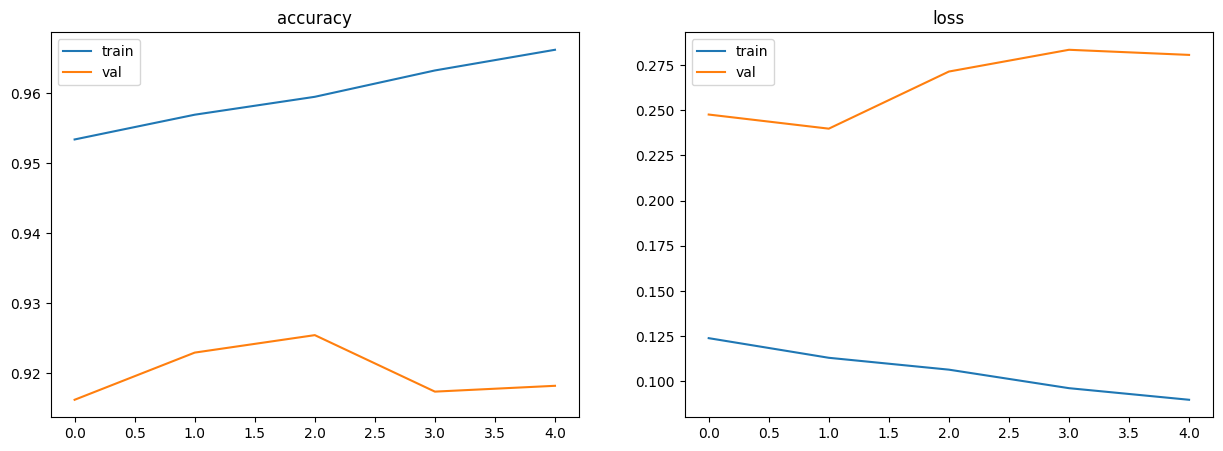

In [49]:
plot_history(history.history)

In [51]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.591 0.    0.003 0.    0.    0.    0.405 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.039 0.    0.961 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.001 0.    0.999 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.003 0.    0.988 0.    0.01  0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.01  0.    0.99  0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.172 0.    0.827 0.    0.001 0.    0.    0.   ]
 [0.    1.    0. 

In [52]:
np.argmax(pred,axis=1)

array([9, 2, 1, 1, 0, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5,
       7, 5, 1])

In [53]:
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


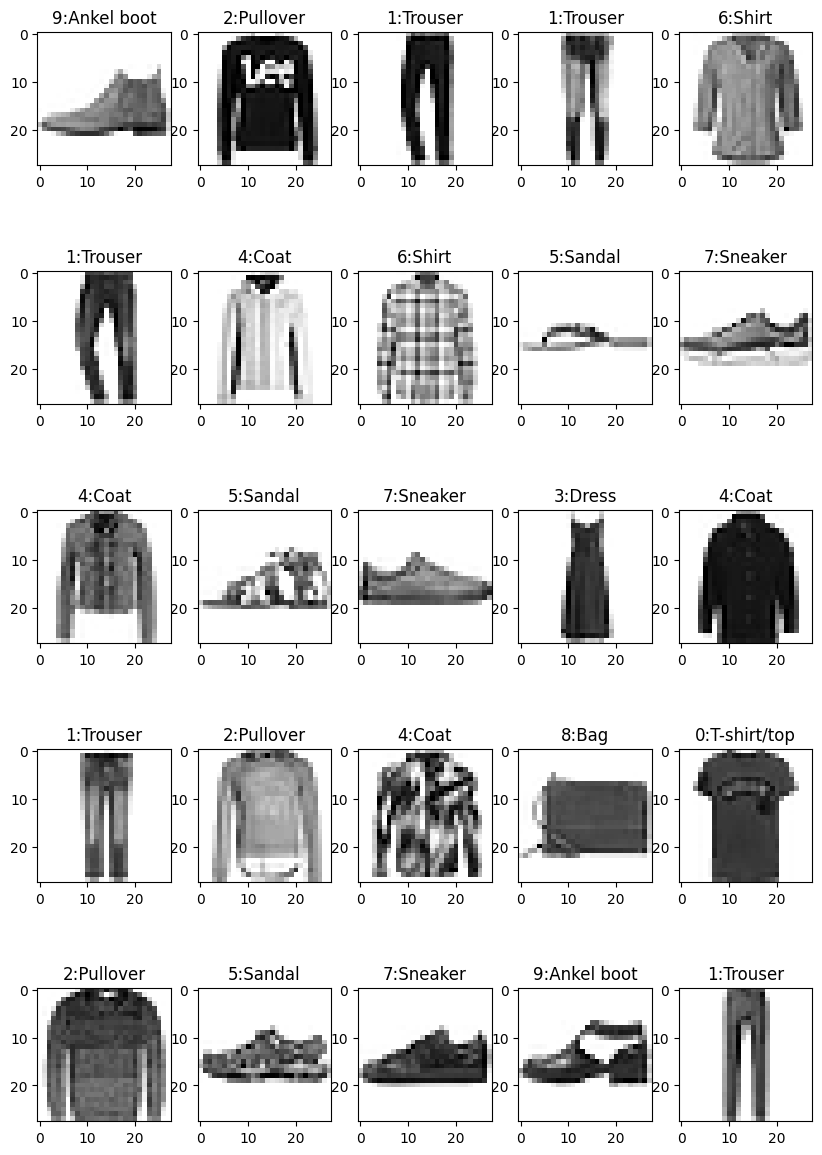

In [54]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')
plt.show()

## CNN의 시각화

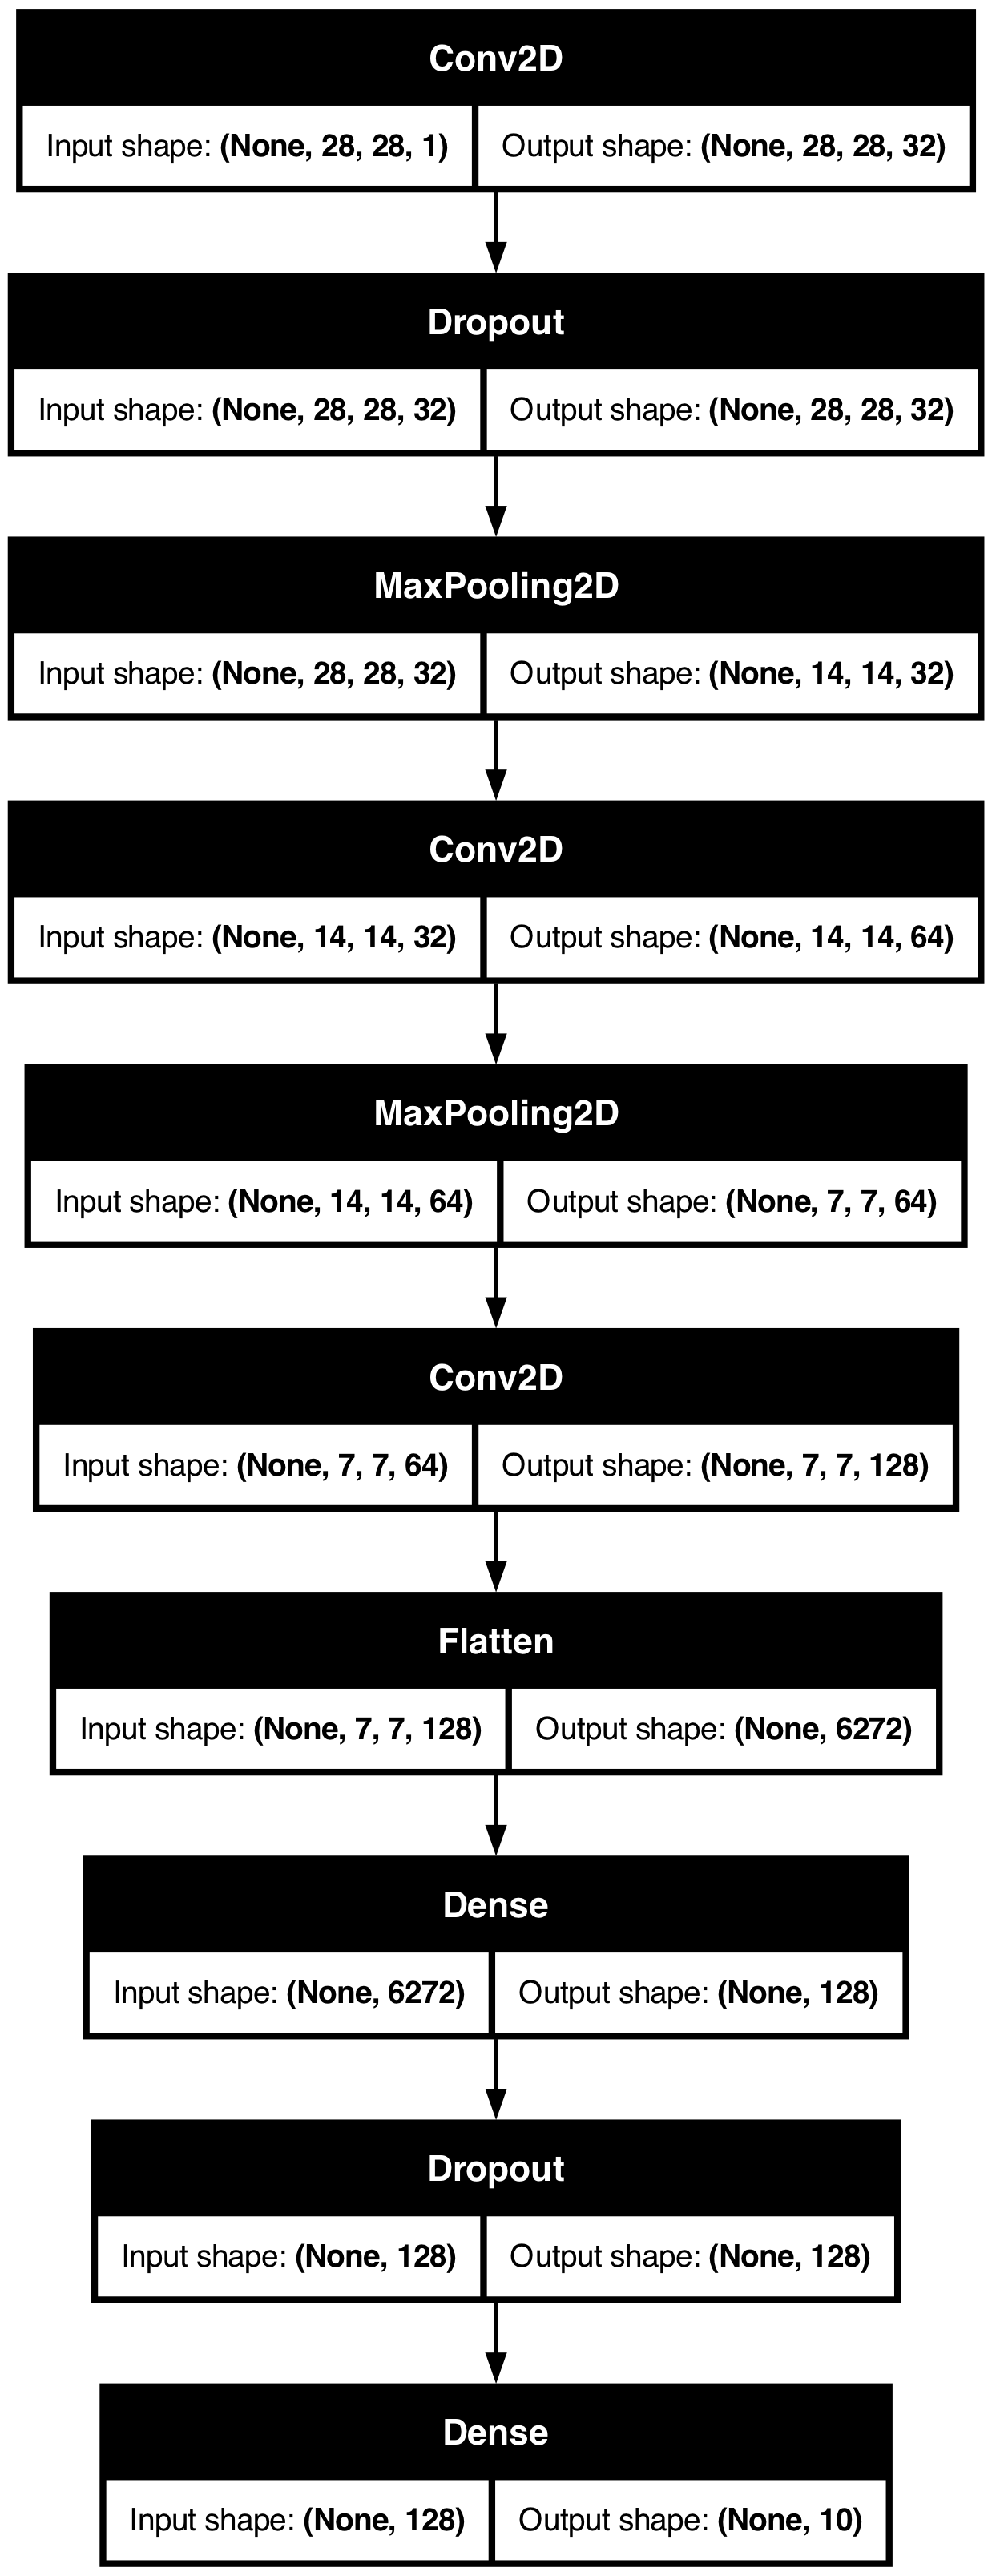

In [55]:
utils.plot_model(model4, show_shapes=True, to_file='fmist.png')

### 학습된 Conv층 가져오기

In [56]:
model5.layers

NameError: name 'model5' is not defined

In [ ]:
conv=model5.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

In [ ]:
weights = conv.weights[0].numpy()
print(weights.shape)
print(weights)

In [ ]:
plt.hist(weights.reshape(-1, 1))
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [ ]:
weights[:, :, 0, 0]

In [ ]:
weights[:, :, 0, 1]

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

In [ ]:
init_model = keras.Sequential()
init_model.add(layers.Conv2D(32, (3,3), activation='relu',
                             padding='same', input_shape=(28,28,1)))
init_model.summary()

In [ ]:
new_conv=init_model.layers[0]
print(new_conv.weights[0].shape, new_conv.weights[1].shape)

In [ ]:
new_weights = new_conv.weights[0].numpy()
print(new_weights.shape)
print(new_weights)

In [ ]:
plt.hist(new_weights.reshape(-1, 1))
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(new_weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

### 필터를 거친 이미지 확인하기

In [ ]:
conv1 = keras.Model(model5.input, model5.layers[0].output)
conv1.summary()

In [ ]:
plt.imshow(x_train2d[0])
plt.show()

In [ ]:
feature_map1 = conv1.predict(x_train[0:1])
print(feature_map1.shape)

In [ ]:
feature_map1[0, :, :, 0]

In [ ]:
feature_map1[0, :, :, 1]

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map1[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [ ]:
model5.layers

In [ ]:
conv2 = keras.Model(model5.input, model5.layers[2].output)
conv2.summary()

In [ ]:
feature_map2 = conv2.predict(x_train[0:1])
print(feature_map2.shape)

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map2[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [ ]:
conv3 = keras.Model(model5.input, model5.layers[3].output)
conv3.summary()

In [ ]:
feature_map3 = conv3.predict(x_train[0:1])
print(feature_map3.shape)

In [ ]:
feature_map3[0,:,:,0]

In [ ]:
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
  for j in range(8):
    axs[i, j].imshow(feature_map3[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()